## Import Libraries

In [ ]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
from galform_analysis.analysis.mass_functions import (
    hmf_given_redshift_and_subvolume,
    compute_theoretical_hmfs
)
from galform_analysis.analysis import hmfs_given_redshifts_and_subvolume

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
base_dir = get_base_dir()

## For a given redshift and sub volume, plot the HMF

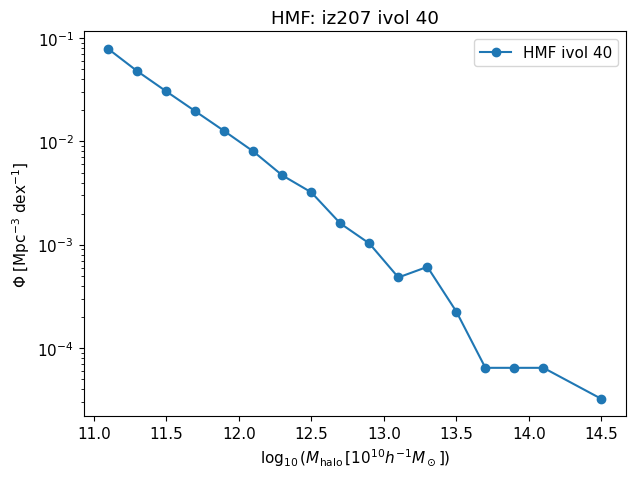

In [ ]:
halo_mass_lower_limit = 1e11

example_snapshot = 'iz207'
example_ivol = 40  

fig, ax = plot_single_hmf_given_redshift_and_subvolume(
    base_dir,
    example_snapshot,
    example_ivol,
    halo_mass_lower_limit=halo_mass_lower_limit,
)

## For a given redshift and subvolume, compare to theoretical HMFs

/cosma/home/durham/dc-hick2/galform_analysis/.venv/lib64/python3.9/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


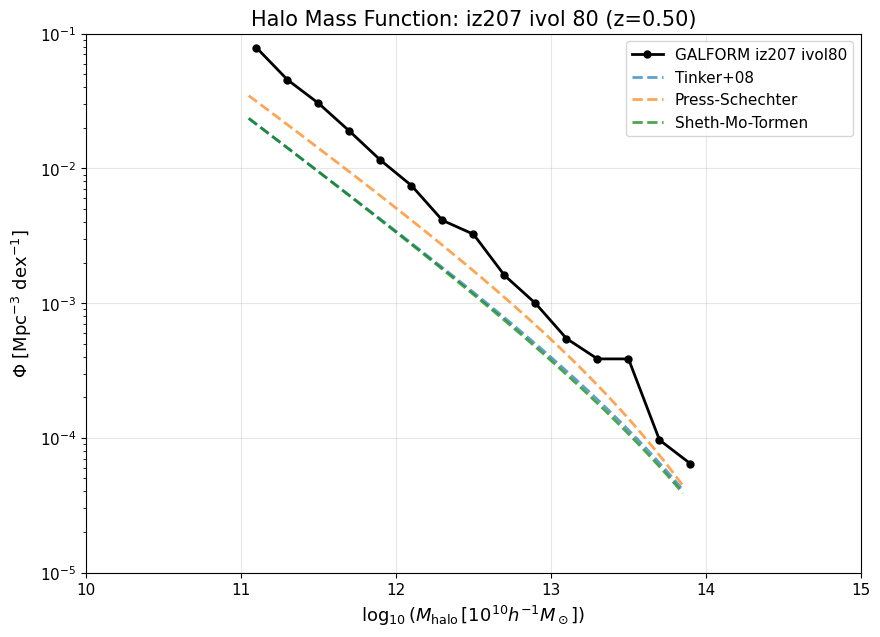

In [3]:
example_snapshot = 'iz207'
example_ivol = 80  

fig, ax = plot_hmf_with_theory(
    base_dir,
    example_snapshot,
    example_ivol,
    halo_mass_lower_limit=halo_mass_lower_limit,
    xlim=(10, 15),
    ylim=(1e-5, 1e-1),
    theory_bins = np.arange(11.0, 14.0, 0.1)
)

## HMFs for different redshifts

Successfully loaded 3 snapshots


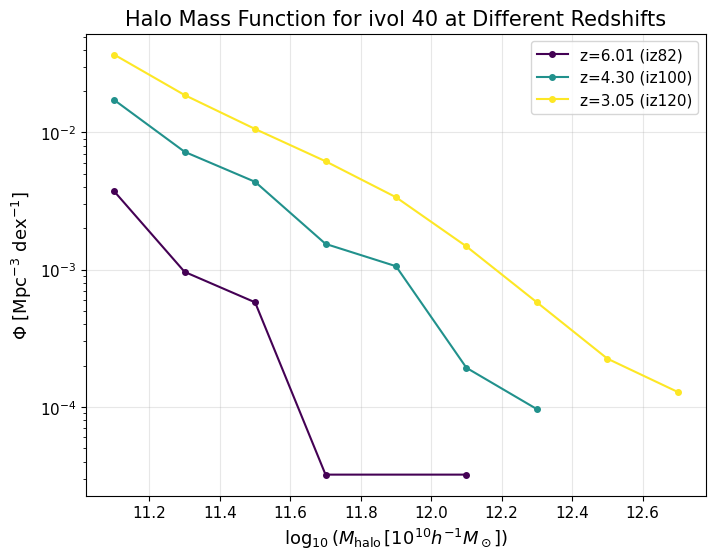

In [4]:
halo_mass_lower_limit = 1e11

example_ivol = 40
iz_nums = [82, 100, 120]

fig, ax, df, results_by_z = plot_hmf_multiple_redshifts(
    base_dir,
    example_ivol,
    iz_nums,
    halo_mass_lower_limit=halo_mass_lower_limit,
    figsize=(8, 6)
)

## For a given sub volume average over given redshifts

Computing HMF for ivol=0 across 3 redshifts
Successfully used 2/3 snapshots
Snapshots: ['iz100', 'iz120']
Redshifts: ['4.30', '3.05']
Successfully used 2/3 snapshots
Snapshots: ['iz100', 'iz120']
Redshifts: ['4.30', '3.05']


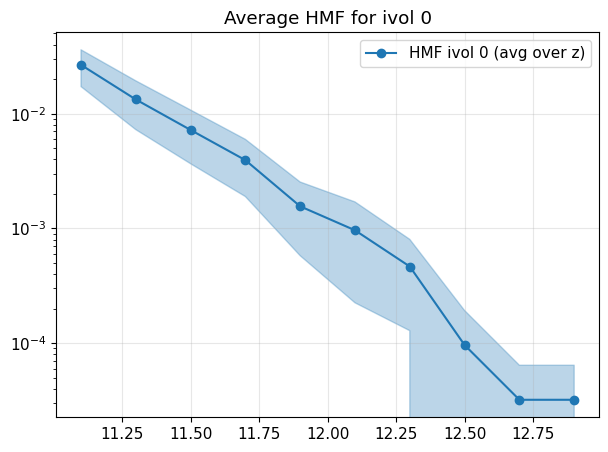

In [5]:
# Example: Average HMF for one subvolume across multiple redshifts
from galform_analysis.analysis import avg_hmf_given_redshifts_and_subvolume

example_ivol = 0  # choose a subvolume
iz_nums = [82, 100, 120]  # snapshots that exist in base_dir

print(f"Computing HMF for ivol={example_ivol} across {len(iz_nums)} redshifts")

result = avg_hmf_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

if result is None:
    print("No valid HMF data. Check that the subvolume exists in these snapshots.")
else:
    print(f"Successfully used {result['n_used']}/{result['n_requested']} snapshots")
    print(f"Snapshots: {result['iz_list']}")
    print(f"Redshifts: {[f'{z:.2f}' for z in result['z_list']]}" )
    
    centers = result['centers']
    phi = result['phi']
    phi_std = result['phi_std']
    
    # Mask to ensure the line ends at last valid point
    valid = np.isfinite(phi) & (phi > 0)
    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_yscale('log')
    ax.plot(centers[valid], phi[valid], 'o-', label=f'HMF ivol {example_ivol} (avg over z)', color='C0')
    ax.fill_between(centers[valid], (phi - phi_std)[valid], (phi + phi_std)[valid], alpha=0.3, color='C0')
    #ax.set_xlabel(r'$\\log_{10}(M_{\\rm halo}/M_\\odot)$')
    #ax.set_ylabel(r'$\\Phi\ \mathrm{[Mpc^{-3}\ dex^{-1}]}$')
    ax.set_title(f'Average HMF for ivol {example_ivol}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()